# Bloc II - Audit de qualité des données

## tl;dr

Ce notebook vérifie si les événements MQTT actuellement conservés sont
suffisamment fiables pour construire les analyses statistiques et le
dashboard du bloc II. Il ne cherche pas encore à démontrer une relation
métier : il contrôle le grain, la couverture temporelle, les doublons,
la complétude et la cohérence des règles thermiques.

**Source contrôlée :** `data/raw/mqtt_raw.db`, table
`raw_mqtt_events`. Les messages ont été produits dans le cadre de la
qualification technique du pipeline ; ils ne constituent pas un
historique industriel longitudinal.

## Context & Methods

### Question de qualité

Le jeu est-il assez complet, homogène et correctement qualifié pour
calculer un taux de conformité thermique par zone et tester les facteurs
associés aux excursions ?

### Grain attendu

Une ligne doit représenter un événement reçu d'un équipement, identifié
par son empreinte `raw_hash`, son horodatage, sa zone et son type de
mesure. La règle `2-8 °C` ne s'applique qu'aux mesures de stockage ou
d'expédition explicitement éligibles.

In [1]:
from pathlib import Path
import json
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import fisher_exact

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

project_root = Path.cwd()
if not (project_root / "data" / "raw" / "mqtt_raw.db").exists():
    project_root = project_root.parent

database_path = project_root / "data" / "raw" / "mqtt_raw.db"
screenshot_dir = project_root / "assets" / "screenshots" / "bloc2"
screenshot_dir.mkdir(parents=True, exist_ok=True)

assert database_path.exists(), f"Base introuvable : {database_path}"
database_path

WindowsPath('C:/Users/MAF/Desktop/certification_data_eng/pharma_coldchain_project/data/raw/mqtt_raw.db')

## Data

### 1. Chargement de la base brute

In [2]:
connection = sqlite3.connect(f"file:{database_path}?mode=ro", uri=True)

raw_events = pd.read_sql_query(
    '''
    SELECT
        id,
        received_at_utc,
        broker,
        topic,
        qos,
        retained,
        payload_json,
        raw_hash,
        classification,
        machine_id AS envelope_machine_id,
        supplier AS envelope_supplier
    FROM raw_mqtt_events
    ORDER BY id
    ''',
    connection,
)

capture_runs = pd.read_sql_query(
    "SELECT * FROM capture_runs ORDER BY id",
    connection,
)
connection.close()

raw_events.shape, capture_runs.shape

((347, 11), (4, 7))

In [3]:
def parse_payload(value):
    if value is None:
        return {}
    try:
        return json.loads(value)
    except (TypeError, json.JSONDecodeError):
        return {"_json_parse_error": True}


payload = pd.json_normalize(raw_events["payload_json"].map(parse_payload))
payload = payload.add_prefix("event_")
events = pd.concat(
    [raw_events.drop(columns=["payload_json"]), payload],
    axis=1,
)

events["received_at_utc"] = pd.to_datetime(
    events["received_at_utc"], utc=True, errors="coerce"
)
events["event_timestamp"] = pd.to_datetime(
    events["event_timestamp"], utc=True, errors="coerce"
)
events["ingestion_delay_seconds"] = (
    events["received_at_utc"] - events["event_timestamp"]
).dt.total_seconds()

events.head(3)

,id,received_at_utc,broker,topic,qos,retained,raw_hash,classification,envelope_machine_id,envelope_supplier,...,event_temperature_c,event_humidity_pct,event_pressure_bar,event_vibration_mm_s,event_motor_current_a,event_rpm,event_cycle_count,event_state,event_alarm_code,ingestion_delay_seconds
0,1,2026-07-01 18:06:27.633898+00:00,mqtt-recette-01,pharma/production/site-042/sensor/SENSOR_06,1,0,421f85c3b2d96325a1fd66d38de1958c94849d62d760cc...,production_machine_signal,SENSOR_06,Endress+Hauser,...,5.84,48.1,1.54,1.12,4.04,1000,13845,RUNNING,None,0.024639
1,2,2026-07-01 18:06:32.632855+00:00,mqtt-recette-01,pharma/production/site-042/compressor/COMP_05,1,0,bd507184432ea1136376367fddbeeaad1adbaa297f476f...,production_machine_signal,COMP_05,ABB,...,22.56,64.5,1.75,4.31,6.97,132,17848,IDLE,None,0.003639
2,3,2026-07-01 18:06:37.637618+00:00,mqtt-recette-01,pharma/production/site-042/sensor/SENSOR_06,1,0,5570ba3b6de84915e7e3a2bff3be2afccaa9c4ab2aa3c3...,production_machine_signal,SENSOR_06,Endress+Hauser,...,3.98,66.7,2.00,0.84,5.14,34,3264,IDLE,None,0.003429


### 2. Profil compact du jeu

In [4]:
required_columns = [
    "raw_hash",
    "received_at_utc",
    "event_timestamp",
    "event_machine_id",
    "event_machine_type",
    "event_zone",
    "event_room_id",
    "event_temperature_c",
    "event_state",
]

profile = pd.DataFrame(
    {
        "indicateur": [
            "Nombre d'événements",
            "Nombre de colonnes après normalisation",
            "Début de couverture",
            "Fin de couverture",
            "Empreintes dupliquées",
            "Messages JSON illisibles",
            "Valeurs requises manquantes",
        ],
        "valeur": [
            len(events),
            len(events.columns),
            events["received_at_utc"].min(),
            events["received_at_utc"].max(),
            int(events["raw_hash"].duplicated(keep=False).sum()),
            int(events.get("event__json_parse_error", pd.Series(False, index=events.index)).sum()),
            int(events[required_columns].isna().sum().sum()),
        ],
    }
)
profile

,indicateur,valeur
0,Nombre d'événements,347
1,Nombre de colonnes après normalisation,31
2,Début de couverture,2026-07-01 18:06:27.633898+00:00
3,Fin de couverture,2026-07-02 13:17:44.206660+00:00
4,Empreintes dupliquées,0
5,Messages JSON illisibles,0
6,Valeurs requises manquantes,0


## Results

### 3. Couverture temporelle et fraîcheur

,received_at_utc,event_count
0,2026-07-01 18:00:00+00:00,233
19,2026-07-02 13:00:00+00:00,114


,id,started_at_utc,ended_at_utc,broker,topics,duration_seconds,status
0,1,2026-07-01T18:06:24.582420+00:00,2026-07-01T18:06:41.655229+00:00,mqtt-recette-01,"[""pharma/production/site-042/#"", ""pharma/coldc...",15,finished stored=3 duplicates=0 ignored=0
1,2,2026-07-01T18:17:58.491246+00:00,None,mqtt-recette-01,"[""pharma/production/site-042/#""]",600,running
2,3,2026-07-01T18:27:45.737792+00:00,2026-07-01T18:37:47.941163+00:00,mqtt-recette-01,"[""pharma/production/site-042/#""]",600,finished stored=120 duplicates=0 ignored=0
3,4,2026-07-02T13:07:45.069519+00:00,2026-07-02T13:17:46.260921+00:00,mqtt-recette-01,"[""pharma/production/site-042/#""]",600,finished stored=114 duplicates=0 ignored=0


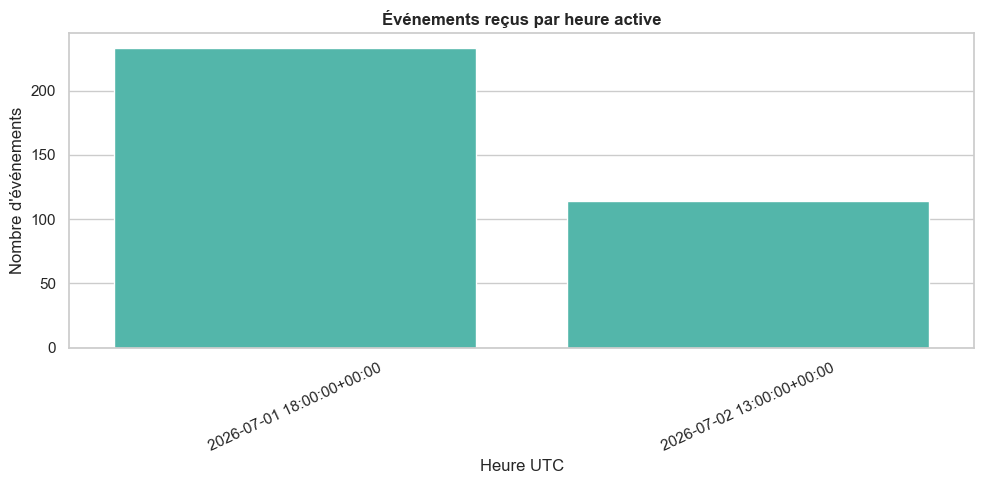

In [5]:
events_by_hour = (
    events.set_index("received_at_utc")
    .resample("h")
    .size()
    .rename("event_count")
    .reset_index()
)
events_by_hour = events_by_hour.loc[events_by_hour["event_count"] > 0]

display(events_by_hour)
display(capture_runs)

figure, axis = plt.subplots()
sns.barplot(
    data=events_by_hour,
    x="received_at_utc",
    y="event_count",
    color="#43C6B6",
    ax=axis,
)
axis.set(
    title="Événements reçus par heure active",
    xlabel="Heure UTC",
    ylabel="Nombre d'événements",
)
axis.tick_params(axis="x", rotation=25)
figure.tight_layout()
figure.savefig(
    screenshot_dir / "01_couverture_temporelle.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### 4. Comparabilité des températures

In [6]:
measurement_rules = pd.DataFrame(
    [
        {
            "event_machine_type": "hvac_cold_room",
            "measurement_context": "cold_storage",
            "threshold_min_c": 2.0,
            "threshold_max_c": 8.0,
            "temperature_rule_eligible": True,
        },
        {
            "event_machine_type": "sensor",
            "measurement_context": "cold_dispatch",
            "threshold_min_c": 2.0,
            "threshold_max_c": 8.0,
            "temperature_rule_eligible": True,
        },
        {
            "event_machine_type": "lyophilizer",
            "measurement_context": "process",
            "threshold_min_c": None,
            "threshold_max_c": None,
            "temperature_rule_eligible": False,
        },
        {
            "event_machine_type": "filling_line",
            "measurement_context": "process",
            "threshold_min_c": None,
            "threshold_max_c": None,
            "temperature_rule_eligible": False,
        },
        {
            "event_machine_type": "autoclave",
            "measurement_context": "process",
            "threshold_min_c": None,
            "threshold_max_c": None,
            "temperature_rule_eligible": False,
        },
        {
            "event_machine_type": "compressor",
            "measurement_context": "utility",
            "threshold_min_c": None,
            "threshold_max_c": None,
            "temperature_rule_eligible": False,
        },
    ]
)

qualified = events.merge(
    measurement_rules,
    on="event_machine_type",
    how="left",
    validate="many_to_one",
)
qualified["naive_outside_2_8"] = ~qualified["event_temperature_c"].between(2, 8)
qualified["qualified_excursion"] = (
    qualified["temperature_rule_eligible"].fillna(False)
    & ~qualified["event_temperature_c"].between(
        qualified["threshold_min_c"],
        qualified["threshold_max_c"],
    )
)

comparison = pd.DataFrame(
    {
        "calcul": [
            "Application uniforme de la règle 2-8 °C",
            "Application aux seules mesures éligibles",
        ],
        "mesures_hors_plage": [
            int(qualified["naive_outside_2_8"].sum()),
            int(qualified["qualified_excursion"].sum()),
        ],
        "mesures_éligibles": [
            len(qualified),
            int(qualified["temperature_rule_eligible"].fillna(False).sum()),
        ],
    }
)
comparison

,calcul,mesures_hors_plage,mesures_éligibles
0,Application uniforme de la règle 2-8 °C,230,347
1,Application aux seules mesures éligibles,2,119


In [7]:
machine_summary = (
    qualified.groupby(
        ["event_machine_id", "event_machine_type", "measurement_context"],
        dropna=False,
    )
    .agg(
        event_count=("id", "size"),
        temperature_min_c=("event_temperature_c", "min"),
        temperature_median_c=("event_temperature_c", "median"),
        temperature_max_c=("event_temperature_c", "max"),
        first_event=("received_at_utc", "min"),
        last_event=("received_at_utc", "max"),
    )
    .reset_index()
)
machine_summary

,event_machine_id,event_machine_type,measurement_context,event_count,temperature_min_c,temperature_median_c,temperature_max_c,first_event,last_event
0,AUTO_03,autoclave,process,52,19.63,21.355,22.73,2026-07-01 18:18:20.526765+00:00,2026-07-02 13:17:44.206660+00:00
1,COMP_05,compressor,utility,70,19.50,21.320,22.78,2026-07-01 18:06:32.632855+00:00,2026-07-02 13:16:14.120994+00:00
2,FILL_02,filling_line,process,53,19.52,20.950,22.76,2026-07-01 18:18:55.577120+00:00,2026-07-02 13:17:39.503290+00:00
3,HVAC_CR_04,hvac_cold_room,cold_storage,57,1.80,4.890,11.01,2026-07-01 18:18:10.506834+00:00,2026-07-02 13:17:09.186898+00:00
4,LYO_01,lyophilizer,process,53,19.51,21.120,22.52,2026-07-01 18:18:15.510928+00:00,2026-07-02 13:17:04.280720+00:00
5,SENSOR_06,sensor,cold_dispatch,62,2.67,5.375,6.79,2026-07-01 18:06:27.633898+00:00,2026-07-02 13:17:34.383792+00:00


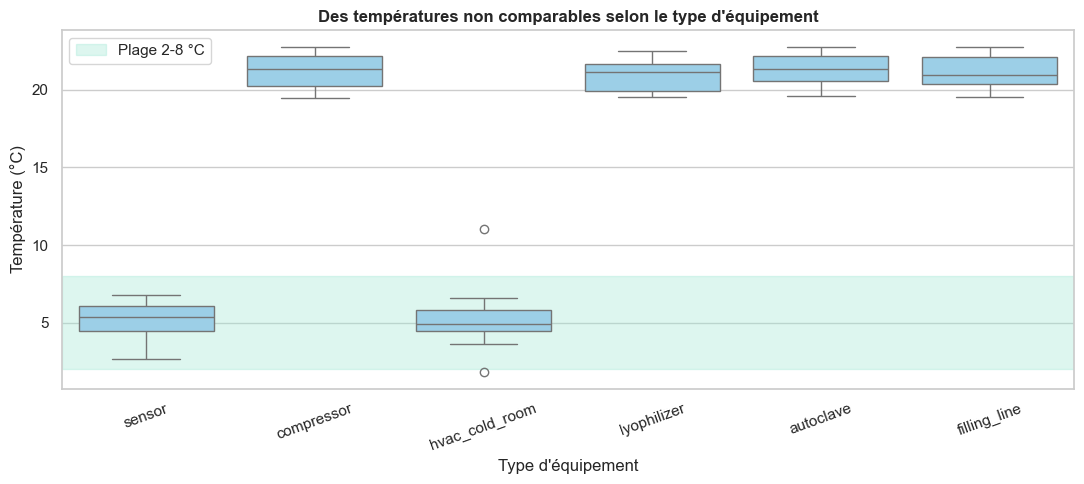

In [8]:
figure, axis = plt.subplots(figsize=(11, 5))
sns.boxplot(
    data=qualified,
    x="event_machine_type",
    y="event_temperature_c",
    color="#8FD3F4",
    ax=axis,
)
axis.axhspan(2, 8, color="#9EE7D2", alpha=0.35, label="Plage 2-8 °C")
axis.set(
    title="Des températures non comparables selon le type d'équipement",
    xlabel="Type d'équipement",
    ylabel="Température (°C)",
)
axis.tick_params(axis="x", rotation=20)
axis.legend()
figure.tight_layout()
figure.savefig(
    screenshot_dir / "02_temperature_par_equipement.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### 5. Régularité des événements et métadonnées de capture

In [9]:
event_gaps = (
    qualified.sort_values(["event_machine_id", "event_timestamp"])
    .groupby("event_machine_id")["event_timestamp"]
    .diff()
    .dt.total_seconds()
)
qualified["gap_seconds"] = event_gaps

gap_summary = (
    qualified.groupby("event_machine_id")
    .agg(
        event_count=("id", "size"),
        median_gap_seconds=("gap_seconds", "median"),
        max_gap_seconds=("gap_seconds", "max"),
    )
    .reset_index()
)

stale_runs = capture_runs[
    capture_runs["ended_at_utc"].isna()
    | capture_runs["status"].str.lower().eq("running")
]

display(gap_summary)
display(stale_runs)

,event_machine_id,event_count,median_gap_seconds,max_gap_seconds
0,AUTO_03,52,25.064240,66711.417708
1,COMP_05,70,15.049717,66631.211599
2,FILL_02,53,20.050017,66706.341479
3,HVAC_CR_04,57,20.073463,66671.300500
4,LYO_01,53,25.099939,66756.533834
5,SENSOR_06,62,20.076198,66651.247270


,id,started_at_utc,ended_at_utc,broker,topics,duration_seconds,status
1,2,2026-07-01T18:17:58.491246+00:00,None,mqtt-recette-01,"[""pharma/production/site-042/#""]",600,running


### 6. Test statistique exploratoire

Le test porte uniquement sur la fenêtre observée. L'hypothèse nulle
`H0` suppose que le statut thermique est indépendant du local. L'hypothèse
alternative `H1` suppose une association entre le local et la présence
d'une mesure hors plage.

Le test exact de Fisher est retenu plutôt qu'un test du khi-deux : il n'y
a que deux écarts et une cellule du tableau de contingence vaut zéro.

In [10]:
eligible = qualified[
    qualified["temperature_rule_eligible"].fillna(False)
].copy()
eligible["statut_thermique"] = eligible["qualified_excursion"].map(
    {False: "Conforme", True: "Hors plage"}
)

room_order = ["CF-008", "QF-002"]
contingency = (
    pd.crosstab(eligible["event_room_id"], eligible["statut_thermique"])
    .reindex(index=room_order, columns=["Conforme", "Hors plage"], fill_value=0)
)
display(contingency)

fisher_table = contingency[["Hors plage", "Conforme"]].to_numpy()
fisher_result = fisher_exact(fisher_table, alternative="two-sided")
alpha = 0.05

room_rates = (
    100
    * contingency["Hors plage"]
    / contingency.sum(axis=1)
)
risk_difference_points = float(room_rates["CF-008"] - room_rates["QF-002"])

fisher_summary = pd.DataFrame(
    {
        "indicateur": [
            "Taux hors plage CF-008",
            "Taux hors plage QF-002",
            "Écart de taux",
            "Odds ratio exact",
            "p-value bilatérale",
            "Seuil alpha",
        ],
        "valeur": [
            f"{room_rates['CF-008']:.2f} %",
            f"{room_rates['QF-002']:.2f} %",
            f"{risk_difference_points:.2f} points",
            str(fisher_result.statistic),
            f"{fisher_result.pvalue:.3f}",
            f"{alpha:.2f}",
        ],
    }
)
display(fisher_summary)

decision = (
    "H0 n'est pas rejetée"
    if fisher_result.pvalue >= alpha
    else "H0 est rejetée"
)
display(
    Markdown(
        f'''
        **Décision statistique : {decision}.** La p-value vaut
        **{fisher_result.pvalue:.3f}**, au-dessus du seuil de 5 %. Le
        local `CF-008` présente deux écarts sur 57 mesures, contre zéro
        sur 62 pour `QF-002`, mais cette fenêtre ne permet pas d'établir
        une association statistiquement significative. L'odds ratio
        exact est infini parce qu'une cellule vaut zéro ; il ne constitue
        pas ici une estimation d'effet stable.
        '''
    )
)

result_path = project_root / "data" / "processed" / "bloc2_fisher_test.json"
result_path.parent.mkdir(parents=True, exist_ok=True)
result_path.write_text(
    json.dumps(
        {
            "test": "Fisher exact bilatéral",
            "hypothese_nulle": "Le statut thermique est indépendant du local.",
            "alpha": alpha,
            "rooms": room_order,
            "table_hors_plage_conforme": fisher_table.tolist(),
            "p_value": float(fisher_result.pvalue),
            "odds_ratio": (
                "infinite"
                if fisher_result.statistic == float("inf")
                else float(fisher_result.statistic)
            ),
            "risk_difference_percentage_points": risk_difference_points,
            "decision": decision,
        },
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)
result_path

statut_thermique,Conforme,Hors plage
event_room_id,,
CF-008,55,2
QF-002,62,0


,indicateur,valeur
0,Taux hors plage CF-008,3.51 %
1,Taux hors plage QF-002,0.00 %
2,Écart de taux,3.51 points
3,Odds ratio exact,inf
4,p-value bilatérale,0.227
5,Seuil alpha,0.05



        **Décision statistique : H0 n'est pas rejetée.** La p-value vaut
        **0.227**, au-dessus du seuil de 5 %. Le
        local `CF-008` présente deux écarts sur 57 mesures, contre zéro
        sur 62 pour `QF-002`, mais cette fenêtre ne permet pas d'établir
        une association statistiquement significative. L'odds ratio
        exact est infini parce qu'une cellule vaut zéro ; il ne constitue
        pas ici une estimation d'effet stable.
        

WindowsPath('C:/Users/MAF/Desktop/certification_data_eng/pharma_coldchain_project/data/processed/bloc2_fisher_test.json')

## Takeaways

In [11]:
eligible_count = int(qualified["temperature_rule_eligible"].fillna(False).sum())
eligible_rate = eligible_count / len(qualified) if len(qualified) else 0
active_hours = len(events_by_hour)
stale_run_count = len(stale_runs)
stale_run_label = (
    "capture non clôturée"
    if stale_run_count == 1
    else "captures non clôturées"
)
duplicate_count = int(events["raw_hash"].duplicated(keep=False).sum())
missing_required = int(events[required_columns].isna().sum().sum())

display(
    Markdown(
        f'''
        - **{len(events)} événements** sont disponibles, concentrés sur
          **{active_hours} heures actives**, entre le
          **{events["received_at_utc"].min():%d/%m/%Y %H:%M UTC}** et le
          **{events["received_at_utc"].max():%d/%m/%Y %H:%M UTC}** :
          la couverture n'est pas encore longitudinale.
        - **{eligible_count} événements ({eligible_rate:.1%})** relèvent
          explicitement du stockage ou de l'expédition sous température
          dirigée.
        - Une règle uniforme `2-8 °C` classe
          **{int(qualified["naive_outside_2_8"].sum())} mesures** hors
          plage, alors que les températures de procédé et d'utilité ne
          sont pas comparables à cette consigne.
        - Les contrôles techniques trouvent **{duplicate_count}
          empreintes dupliquées** et **{missing_required} valeurs
          requises manquantes**.
        - Le registre contient **{stale_run_count}
          {stale_run_label}** dans les métadonnées.

        **Décision :** le jeu est utilisable pour qualifier le pipeline
        et préparer le modèle analytique. Le test exact de Fisher ne
        rejette pas l'indépendance entre le local et le statut thermique
        sur cette fenêtre (**p = {fisher_result.pvalue:.3f}**). Ce résultat
        ne démontre ni l'équivalence des locaux ni l'absence de risque :
        la prochaine collecte doit couvrir plusieurs jours, plusieurs
        zones froides et des variables opérationnelles telles que la
        consigne, l'ouverture de porte et l'état du groupe froid.
        '''
    )
)


        - **347 événements** sont disponibles, concentrés sur
          **2 heures actives**, entre le
          **01/07/2026 18:06 UTC** et le
          **02/07/2026 13:17 UTC** :
          la couverture n'est pas encore longitudinale.
        - **119 événements (34.3%)** relèvent
          explicitement du stockage ou de l'expédition sous température
          dirigée.
        - Une règle uniforme `2-8 °C` classe
          **230 mesures** hors
          plage, alors que les températures de procédé et d'utilité ne
          sont pas comparables à cette consigne.
        - Les contrôles techniques trouvent **0
          empreintes dupliquées** et **0 valeurs
          requises manquantes**.
        - Le registre contient **1
          capture non clôturée** dans les métadonnées.

        **Décision :** le jeu est utilisable pour qualifier le pipeline
        et préparer le modèle analytique. Le test exact de Fisher ne
        rejette pas l'indépendance entre le local et le statut thermique
        sur cette fenêtre (**p = 0.227**). Ce résultat
        ne démontre ni l'équivalence des locaux ni l'absence de risque :
        la prochaine collecte doit couvrir plusieurs jours, plusieurs
        zones froides et des variables opérationnelles telles que la
        consigne, l'ouverture de porte et l'état du groupe froid.
        